# Deep dive into the ArcGIS Python API

 - ## Rohit Singh rsingh@esri.com
 - ## Matthias Schenker m.schenker@esri.ch
 <br/>
 <br/>
 
 <p><center>
 <img src="ScienceOfWhere.PNG"/>
 </center>

# ArcGIS Python API
## What is it?

* Python API to your Web GIS

* Powerful, modern and easy to use

* Implemented using REST + local capabilities

# API Overview
## Pythonic GIS API
<img src="api-overview.png" />

# The GIS Module
<img src="http://esri.github.io/arcgis-python-api/notebooks/nbimages/guide_gis_module_01.png" />

## Connect to <i>your</i> web GIS

In [77]:
from arcgis.gis import GIS

In [78]:
arcgis_online = GIS()

In [7]:
from getpass import getpass
portal = GIS('https://gis.acme.com/portal', 'rohitgeo',  getpass())

········


In [41]:
gis = GIS('https://deldev.maps.arcgis.com', 'deldev', getpass())

········


# Content Management

* Add, remove and update geospatial data, web maps, layers...
* Publish geospatial data as web layers
* Share content with groups, org or everyone


## Add geospatial data

In [16]:
properties = {
    "type" : "File Geodatabase",
    "title" : "city locations",
    "tags" : "cities",
    "description" : "Lots of cities"
}
data_path = r"C:\xc\Presentations\brownbagApril2017\cities.zip"
cities_data = gis.content.add(data=data_path, item_properties=properties)

In [17]:
cities_data

<Item title:"city locations" type:File Geodatabase owner:deldev>

## Publish geospatial data as feature layer

In [18]:
cities = cities_data.publish()
cities.share(True)
cities

<Item title:"city locations" type:Feature Service owner:deldev>

In [19]:
cities.delete()
cities_data.delete()

True

## Search for content

In [194]:
items = gis.content.search('Chennai', 'Feature Layer')

<Item title:"Lakes in Chennai" type:Feature Service owner:deldev>
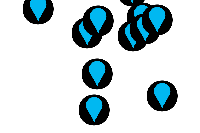

<Item title:"ChennaiFloodsSatellite" type:Feature Service owner:deldev>
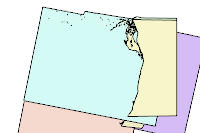

<Item title:"Enriched Chennai Population" type:Feature Service owner:deldev>
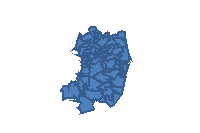

<Item title:"Routes to Chennai Relief Centers" type:Feature Service owner:deldev>

<Item title:"Trace Downstream from Chennai Lakes" type:Feature Service owner:deldev>
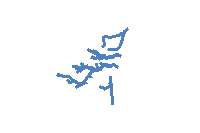

<Item title:"chennai-rainfall" type:Feature Service owner:demo_deldev>

<Item title:"Chennai_rnfl" type:Feature Service owner:demo_deldev>

<Item title:"Chennai_precipitation" type:Feature Service owner:demo_deldev>

In [196]:
from IPython.display import display
for item in items:
    display(item)

# Feature layers

<Item title:"Lakes in Chennai" type:Feature Service owner:deldev>
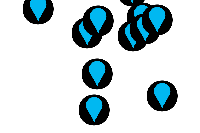

In [34]:
lakes = items[1]
lakes

In [35]:
lakes.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/lakes/FeatureServer/0">]

## The map widget

In [192]:
m = gis.map('Chennai')
m

In [197]:
m.add_layer(lakes)

In [199]:
import time
for basemap in m.basemaps:
    m.basemap = basemap
    print(basemap)
    time.sleep(2)

streets
satellite
hybrid
topo
gray
dark-gray
oceans
national-geographic
terrain
osm


## Spatial analysis

In [179]:
lakemap = gis.map('Chennai')
lakemap.add_layer(lakes)
lakemap

In [49]:
from arcgis.features.find_locations import trace_downstream
from arcgis.features.use_proximity import create_buffers

floodprone_buffer = create_buffers(trace_downstream(lakes),
                                   distances=[500, 1000], units='Meters')

In [180]:
lakemap.add_layer(floodprone_buffer)

## Query features

In [204]:
counties_item = arcgis_online.content.search('USA Counties', 'Feature Layer')[0]
counties_item

<Item title:"USA Counties" type:Feature Service owner:esri_dm>

In [205]:
counties = counties_item.layers[0]

In [206]:
ca_counties = counties.query(where="STATE_NAME='California'")

## Spatial dataframe

In [218]:
counties_df = ca_counties.df
counties_df

,AGE_10_14,AGE_15_19,AGE_20_24,AGE_25_34,AGE_35_44,AGE_45_54,AGE_55_64,AGE_5_9,AGE_65_74,AGE_75_84,...,POP10_SQMI,POP12_SQMI,POP2010,POP2012,RENTER_OCC,SQMI,STATE_NAME,VACANT,WHITE,SHAPE
0,68473,72493,65339,122046,108500,108479,77285,68694,43502,23473,...,102.9,104.282870,839631,851089,101782,8161.35,California,29757,499766,"{'rings': [[[-13119789.4732166, 4272899.442060..."
1,11324,11356,13158,25589,21878,20282,12924,11564,6844,3809,...,109.9,111.427421,152982,155039,18904,1391.39,California,2634,83027,"{'rings': [[[-13342775.4280577, 4356085.351079..."
2,3888,4190,3362,6603,7095,10255,10625,3574,6553,3502,...,48.6,49.082334,64665,65253,9076,1329.46,California,8944,52033,"{'rings': [[[-13667224.3154792, 4696180.986610..."
3,1853,2107,2831,6337,5513,5447,4113,1595,1984,1041,...,7.4,7.422856,34895,35039,3468,4720.42,California,2652,25532,"{'rings': [[[-13418482.3589672, 5039533.376017..."
4,678845,753630,752788,1475731,1430326,1368947,1013156,633690,568470,345603,...,2402.3,2423.264150,9818605,9904341,1696455,4087.19,California,203872,4936599,"{'rings': [[[-13149469.25, 3995666.625], [-131..."
5,11755,12224,11032,20562,19167,19291,15833,11756,9868,5468,...,70.1,71.065672,150865,153025,15591,2153.29,California,5823,94456,"{'rings': [[[-13337486.1875, 4418437.5625], [-..."
6,14241,12798,10308,24836,36478,42055,40088,15481,23211,12425,...,480.2,486.100489,252409,255509,38573,525.63,California,8004,201963,"{'rings': [[[-13691681.78125, 4611910], [-1369..."
7,987,1026,827,1651,1828,3232,3283,821,2253,1186,...,12.5,12.613887,18251,18455,2466,1463.07,California,2495,16103,"{'rings': [[[-13364133.625, 4464660.5], [-1336..."
8,5390,5613,4874,10704,10268,12476,14417,5259,7556,3983,...,25.0,25.083070,87841,88094,14344,3512.09,California,5378,67218,"{'rings': [[[-13752510.6332503, 4689126.202854..."
9,22115,24451,20195,35060,31967,31007,22645,22167,13205,7717,...,129.4,129.897434,255793,256841,34446,1977.26,California,8056,148381,"{'rings': [[[-13401606.6535612, 4527640.672262..."


## Pandorable (attribute and spatial) selections

In [208]:
ventura_county = counties_df[counties_df.NAME == 'Ventura']

In [209]:
# Attribute query
ventura_county.POP2012.iloc[0]

825977

In [210]:
# query the shape of ventura county and set it's spatial reference
ventura_geom = ventura_county.SHAPE.iloc[0]
ventura_geom.spatial_reference = counties.container.properties.spatialReference

## Exploratory data analysis

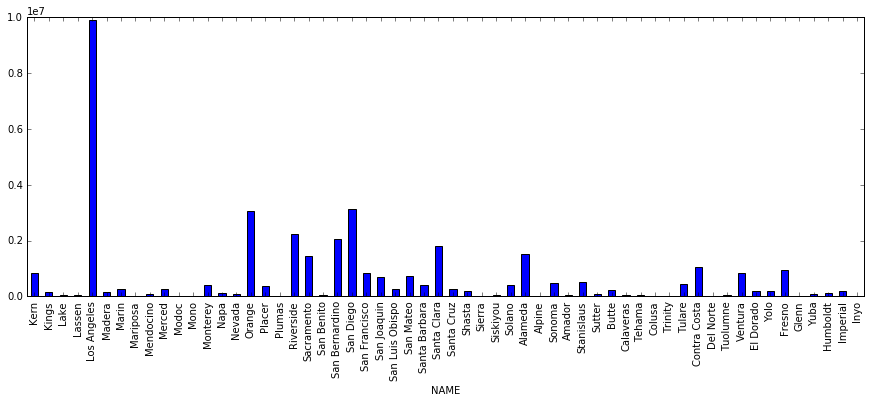

In [224]:
%matplotlib inline
plotdf = counties_df.set_index('NAME')
plotdf.POP2012.plot(kind='bar', x='NAME', figsize=(15,5))

## Smart Mapping

In [183]:
ca_map = arcgis_online.map("California")
ca_map

In [226]:
ca_map.add_layer(counties, 
                 {
                     "definition_expression": "STATE_NAME='California'",
                     "renderer": "ClassedSizeRenderer",
                     "field_name": "POP2012"
                 })

# Imagery layers and raster analysis

In [63]:
landsat_item = arcgis_online.content.search('"Landsat Multispectral"', 
                                            'Imagery Layer')[0]

In [64]:
landsat_item

<Item title:"Multispectral Landsat" type:Image Service owner:esri>

In [65]:
landsat = landsat_item.layers[0]

In [66]:
import pandas as pd
pd.DataFrame(landsat.key_properties()['BandProperties'])

,BandIndex,BandName,DatasetTag,WavelengthMax,WavelengthMin
0,0,CoastalAerosol,MS,450,430
1,1,Blue,MS,510,450
2,2,Green,MS,590,530
3,3,Red,MS,670,640
4,4,NearInfrared,MS,880,850
5,5,ShortWaveInfrared_1,MS,1650,1570
6,6,ShortWaveInfrared_2,MS,2290,2110
7,7,Cirrus,MS,1380,1360


## Visualize imagery layers

In [184]:
zurich = gis.map('Zurich, Switzerland')
zurich

In [227]:
zurich.add_layer(landsat)

## Get spectral profile at clicked location

In [228]:
from bokeh.models import Range1d
from bokeh.plotting import figure, show, output_notebook
from IPython.display import clear_output

output_notebook()

def handle_click(m, pt):
    m.draw(pt)
    
    samples = landsat.get_samples(pt, pixel_size=30)
    values = samples[0]['value']
    
    x = ['1','2', '3', '4', '5', '6', '7', '8']
    y = [float(int(s)/100000) for s in values.split(' ')]
    
    p = figure(title="Spectral Profile", x_axis_label='Spectral Bands', 
               y_axis_label='Data Values', width=600, height=300)
    p.line(x, y, legend="Selected Point", line_color="red", line_width=2)
    p.circle(x, y, line_color="red", fill_color="white", size=8)
    p.set(y_range=Range1d(0, 1.0))
    
    clear_output()
    show(p)

Loading BokehJS ...

In [229]:
zurich.on_click(handle_click)

## Get spectral profile at clicked location

In [187]:
zurich

## Dynamic raster processing

In [188]:
zurich

In [189]:
from arcgis.raster.functions import *

In [230]:
for rasterfunc in landsat.properties.rasterFunctionInfos:
    clear_output()
    print(rasterfunc.name)
    
    zurich.add_layer(apply(landsat, rasterfunc.name))
    time.sleep(2)

None


## Custom raster processing using Raster Functions

<img src="raster-functions2.png"/>

## Raster function chains

In [192]:
zurichmap = arcgis_online.map('Zurich, Switzerland')
zurichmap

In [191]:
land_water_boundary = stretch(extract_band(landsat, [4, 5, 3]),
                              stretch_type='percentclip', 
                              min_percent=1, max_percent=1, gamma=[1, 1, 1], 
                              dra=True)

In [210]:
zurichmap.add_layer(land_water_boundary)

## Where do I go hiking?

* Out in nature, away from people
* Not too high up in the mountains, and...
* Not too steep

<img src="mapalgebra.png"/>
<b>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Weighted overlay analysis</b>


## Function chain for weighted overlay analysis

<img src="rft-woa.png"/>

In [13]:
#portal = GIS('https://dev004546.esri.com/portal', 'djohnsonRA',  'M62evVB12pl') #getpass())

portal = GIS('https://dev004543.esri.com/arcgis', 'djohnsonRA', "M62evVB12pl")

## Inputs
### Elevation raster

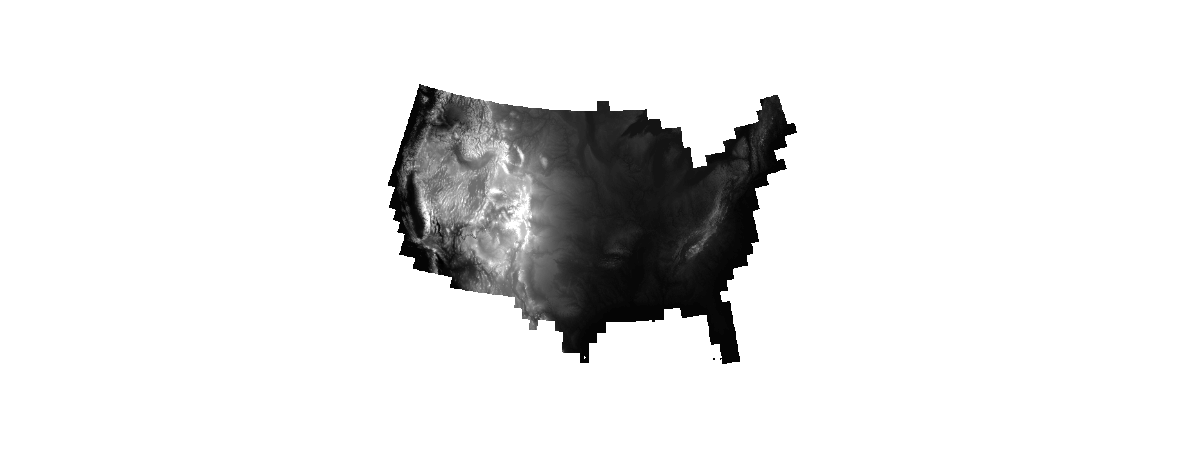

In [14]:
# Digital elevation model for the US

item_dem = portal.content.search('USGS NED 30m')[0]
lyr_dem = item_dem.layers[0]
lyr_dem

### Human modified index

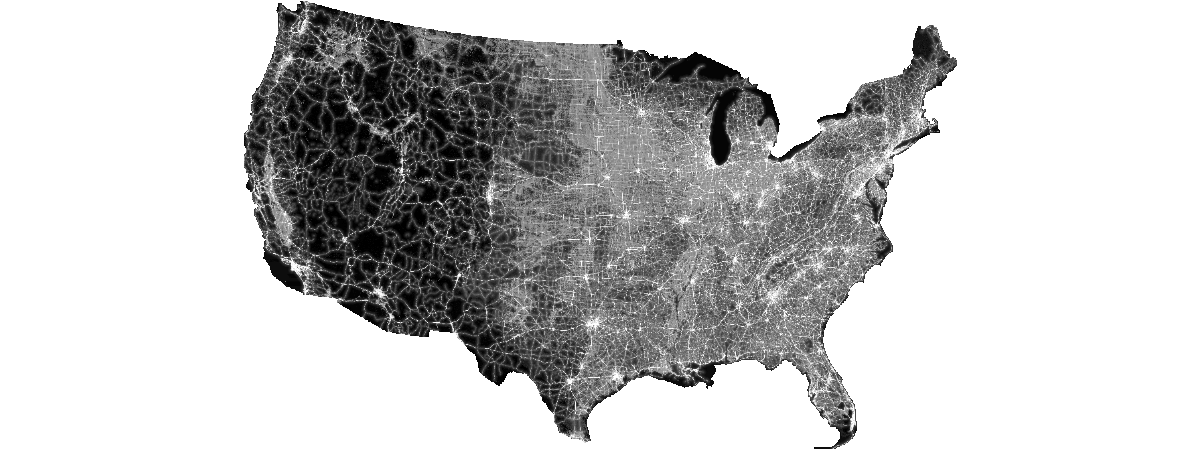

In [15]:
# Human Modified Index imagery layer
# This dataset is based on research on the degree of human modification to
# the landscape, on a scale of 0 - 1, where 0.0 indicates unmodified natural
# landscape and 1.0 indicates the landscape is completely modified by human activity.

item_hmi = portal.content.search('Human_Modification_for_North_America')[0]
lyr_hmi = item_hmi.layers[0]
lyr_hmi

## Set area of interest as layer's extent

In [16]:
# geocode the area of interest
from arcgis.geocoding import geocode

ventura_county = geocode('Ventura County', out_sr=lyr_dem.properties.spatialReference)[0]

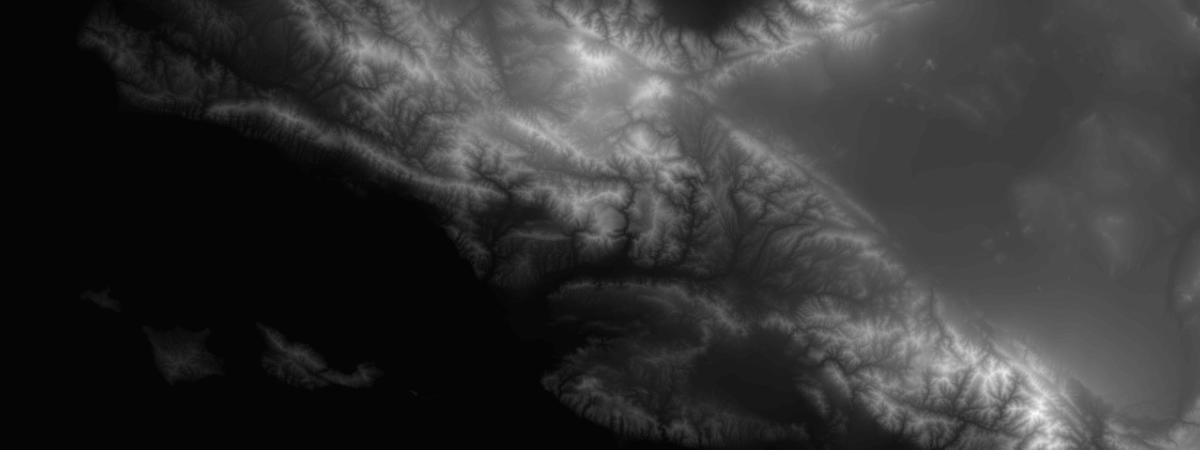

In [17]:
# set the area of interest as the layer's extent
lyr_dem.extent = ventura_county['extent']
lyr_dem

## Weighted overlay analysis using Map Algebra

In [18]:
# Create a colormap for rendering the analysis results.

colormap = [[1, 230, 0, 0],[2, 242, 85, 0],[3, 250, 142, 0],[4, 255, 195, 0],
             [5, 255, 255, 0],[6, 197, 219, 0],[7, 139, 181, 0],[8, 86, 148, 0],
             [9, 38, 115, 0]]

In [27]:
from arcgis.raster.functions import *

# Generate a final result from start to finish in a single operation.
# In this example, slope is assigned a higher weight than elevation or degree of human modification
# on the assumption that slope would have a greater affect of travel cost than the other variables.
weighted_overlay = colormap(
        
        0.25 * remap(clip(lyr_dem, ventura_geom),  # Elevation 
                    input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 1500,2000, 2000,2500, 2500,3000, 3000,5000],
                    output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        
        0.5 * remap(clip(slope(lyr_dem, slope_type='DEGREE', z_factor=1), ventura_geom), # Slope 
                     input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
                     output_values=[1,2,3,4,5,6,7,8,9]) 
        + 
        
        0.25 * remap(clip(lyr_hmi, ventura_geom), # Human modified index 
                     input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                     output_values=[1,2,3,4,5,6,7,8,9]),
        colormap=colormap)

## Visualize results using map widget

In [25]:
imagery_map = gis.map('Ventura County, CA')
imagery_map.add_layer(weighted_overlay)
imagery_map

<img src="where-do-i-hike-map-widget.png"/>

## Persist results as an imagery layer

In [65]:
# Generate a persistent result at source resolution using Raster Analytics

weighted_overlay.save('WeightedOverlayAnalysis')

<Item title:"WeightedOverlayAnalysis" type:Image Service owner:djohnsonRA>

## Results: finding solitude by applying GIS

<img src="race.png" />

## What we covered

* GIS Module
* Features and spatial analysis
* Imagery and raster analysis

## There's a lot more!

* Geoanalysics (bigdata analysis)
* Distributed raster analysis
* Geoprocessing
* Geocoding, batch geocoding, reverse geocoding
* Network analysis, routing, ...

# Thank you!
<p>

### Try it out:

 * conda install -c esri arcgis 
 * conda install -c esri/label/beta arcgis 

### Website: http://developers.arcgis.com/python


### GitHub: http://github.com/esri/arcgis-python-api